# 01 — 数据探索与可视化

本 Notebook 用于初步探索学生成绩数据集。

## 目标
- 加载原始数据
- 查看数据基本信息（shape, dtypes, missing values）
- 描述性统计分析
- 可视化单变量分布（直方图、箱线图）
- 可视化双变量关系（相关性热力图、散点图）
- 初步发现与 insights

✅ 数据加载成功，共 395 行，33 列
📊 数据前5行：
  school sex  age address famsize Pstatus  Medu  Fedu     Mjob      Fjob  ...  \
0     GP   F   18       U     GT3       A     4     4  at_home   teacher  ...   
1     GP   F   17       U     GT3       T     1     1  at_home     other  ...   
2     GP   F   15       U     LE3       T     1     1  at_home     other  ...   
3     GP   F   15       U     GT3       T     4     2   health  services  ...   
4     GP   F   16       U     GT3       T     3     3    other     other  ...   

  famrel freetime  goout  Dalc  Walc health absences  G1  G2  G3  
0      4        3      4     1     1      3        6   5   6   6  
1      5        3      3     1     1      3        4   5   5   6  
2      4        3      2     2     3      3       10   7   8  10  
3      3        2      2     1     1      5        2  15  14  15  
4      4        3      2     1     2      5        4   6  10  10  

[5 rows x 33 columns]

📋 数据类型：
school        object
sex           object
age   

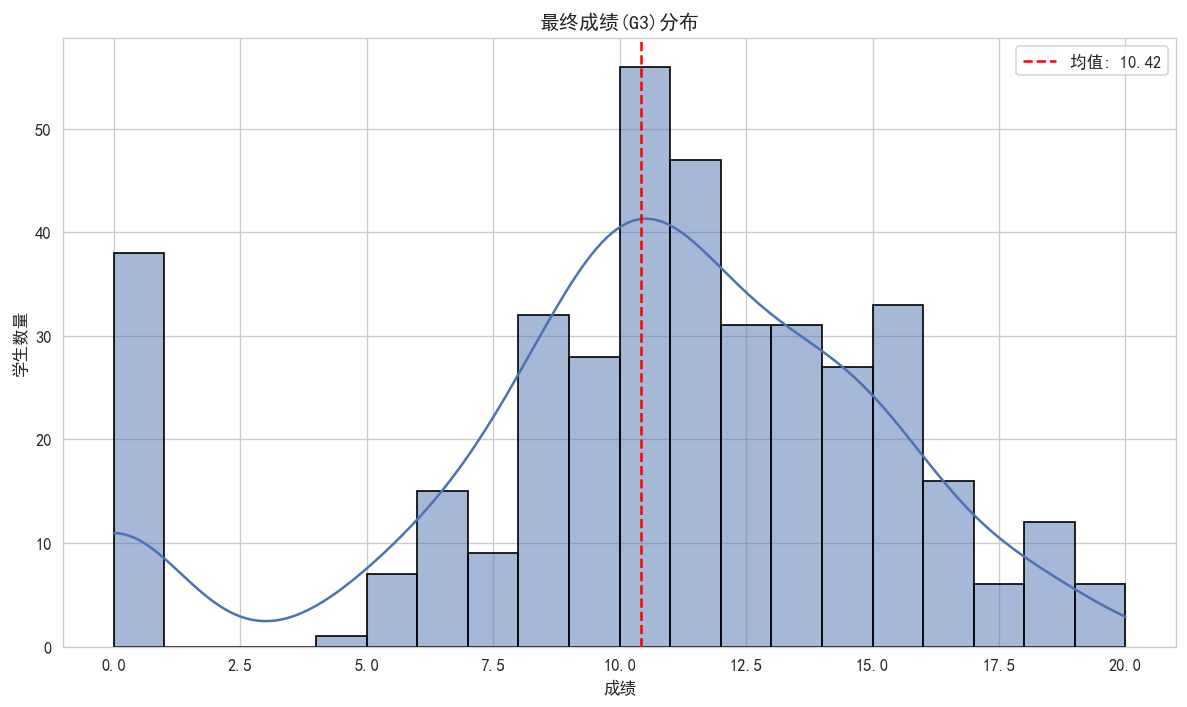

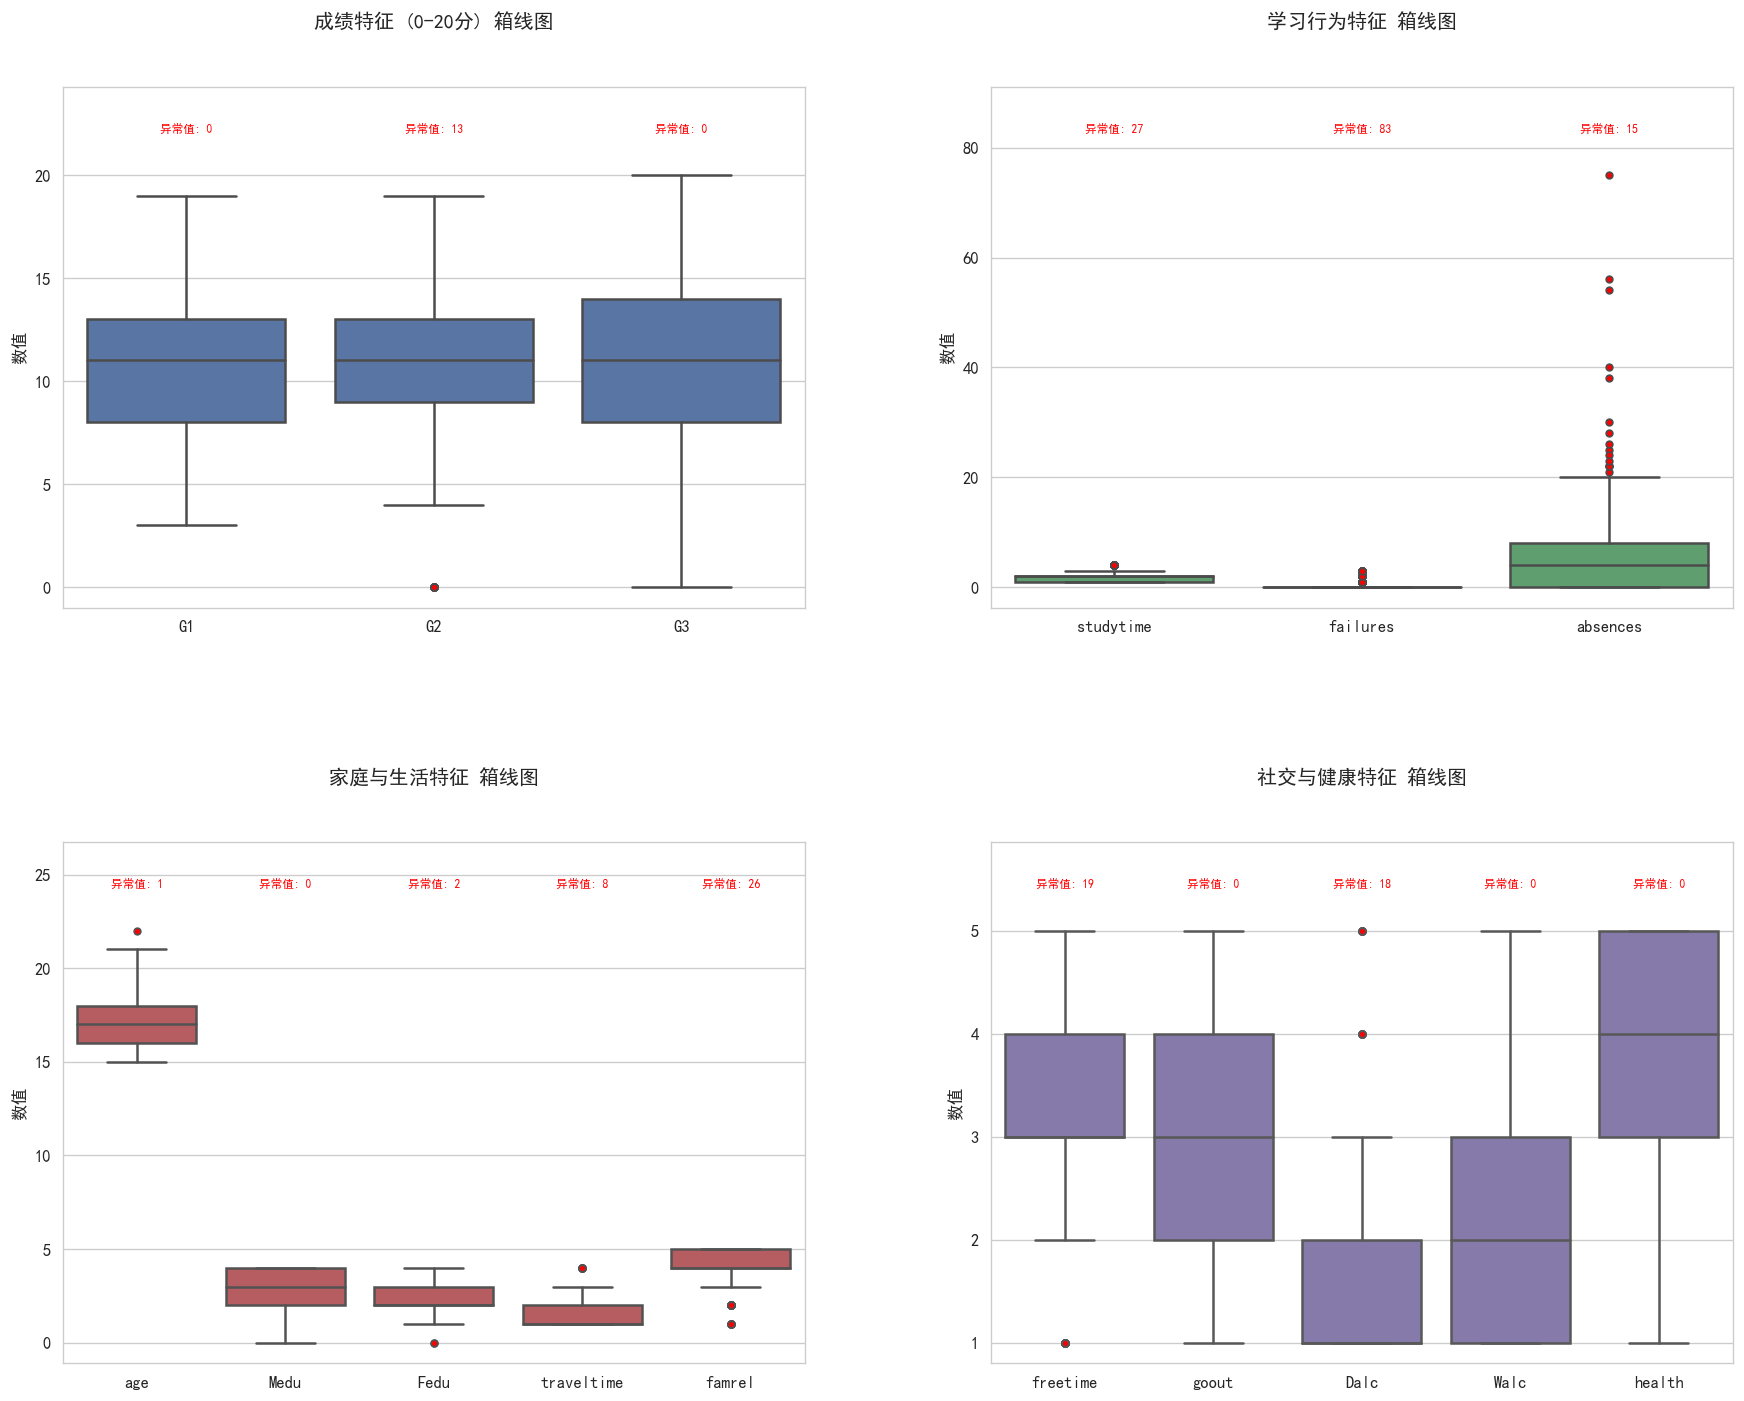


📊 异常值统计汇总：
      特征名称  异常值数量
  failures     83
 studytime     27
    famrel     26
  freetime     19
      Dalc     18
  absences     15
        G2     13
traveltime      8
      Fedu      2
       age      1
      Medu      0
     goout      0
      Walc      0
    health      0
        G1      0
        G3      0


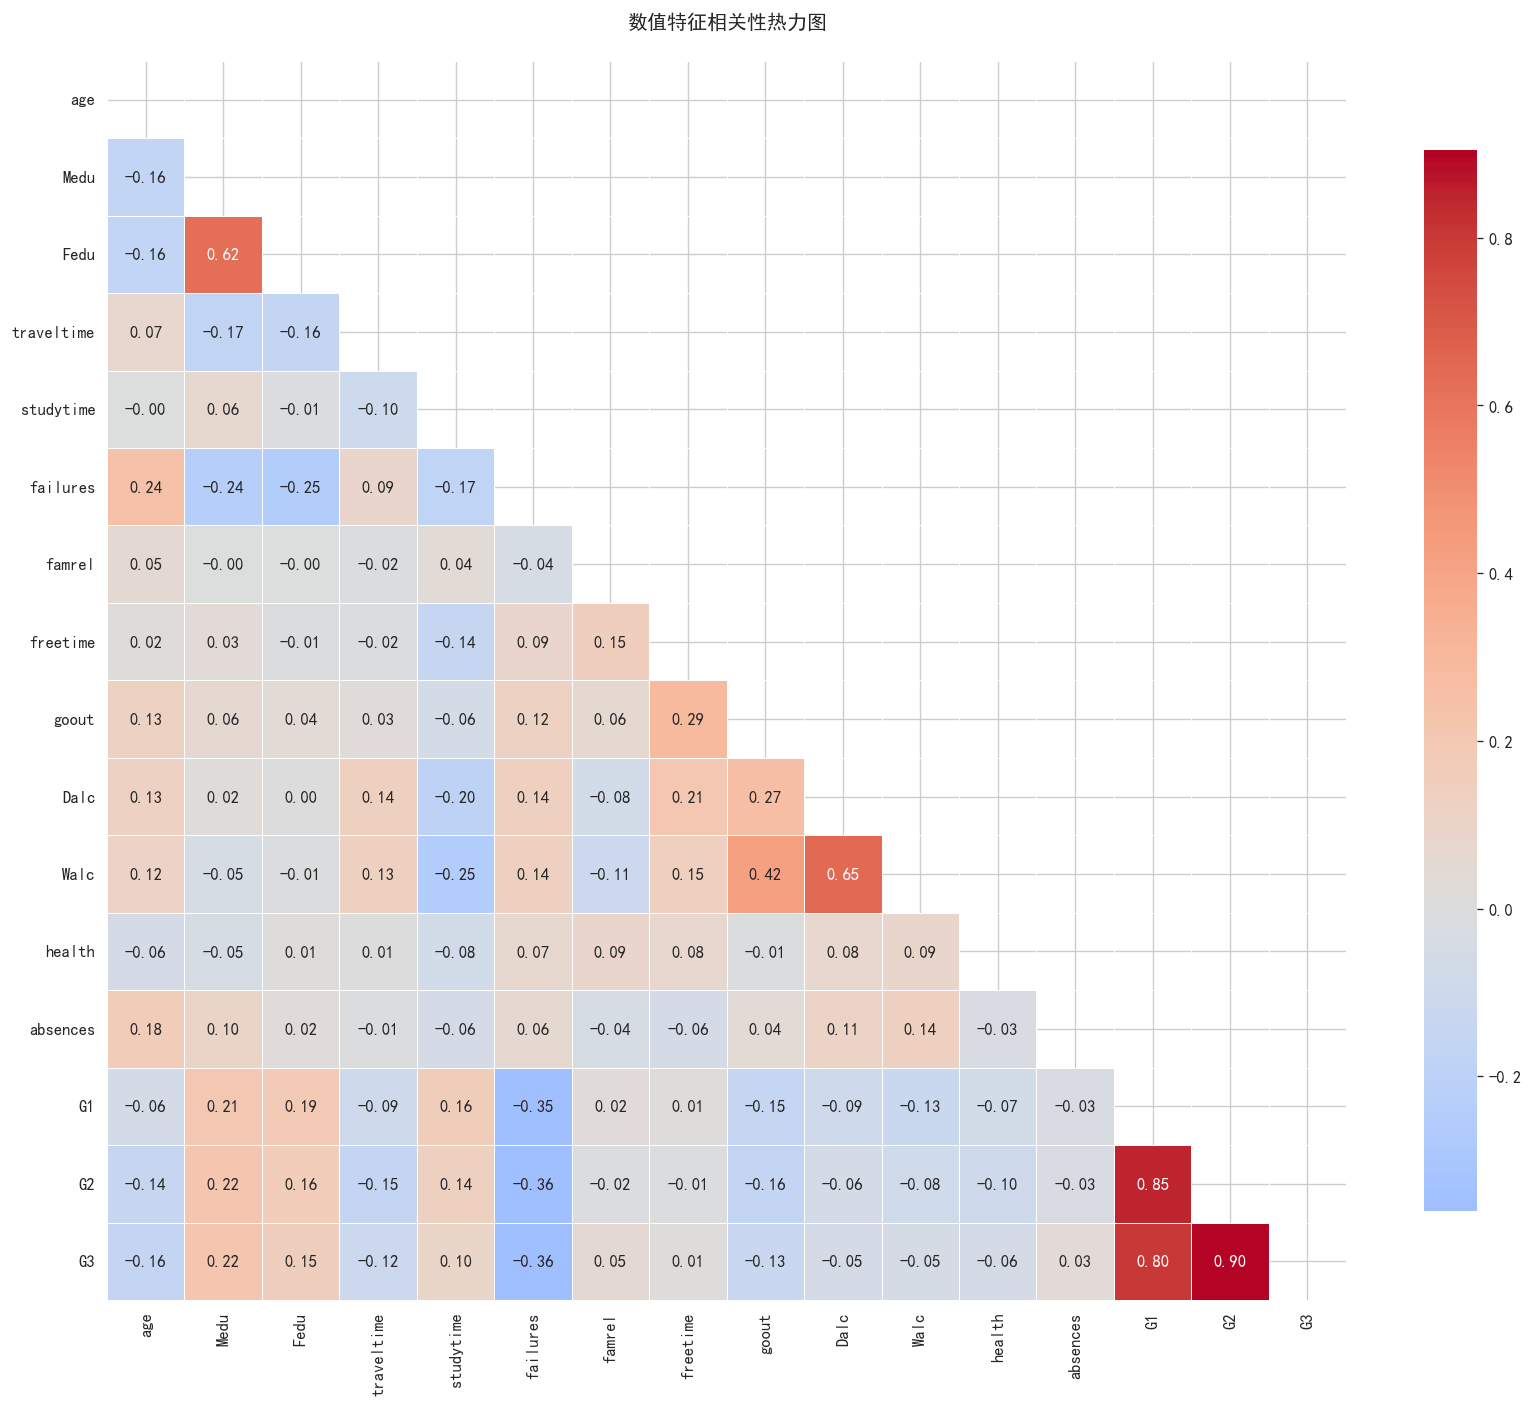

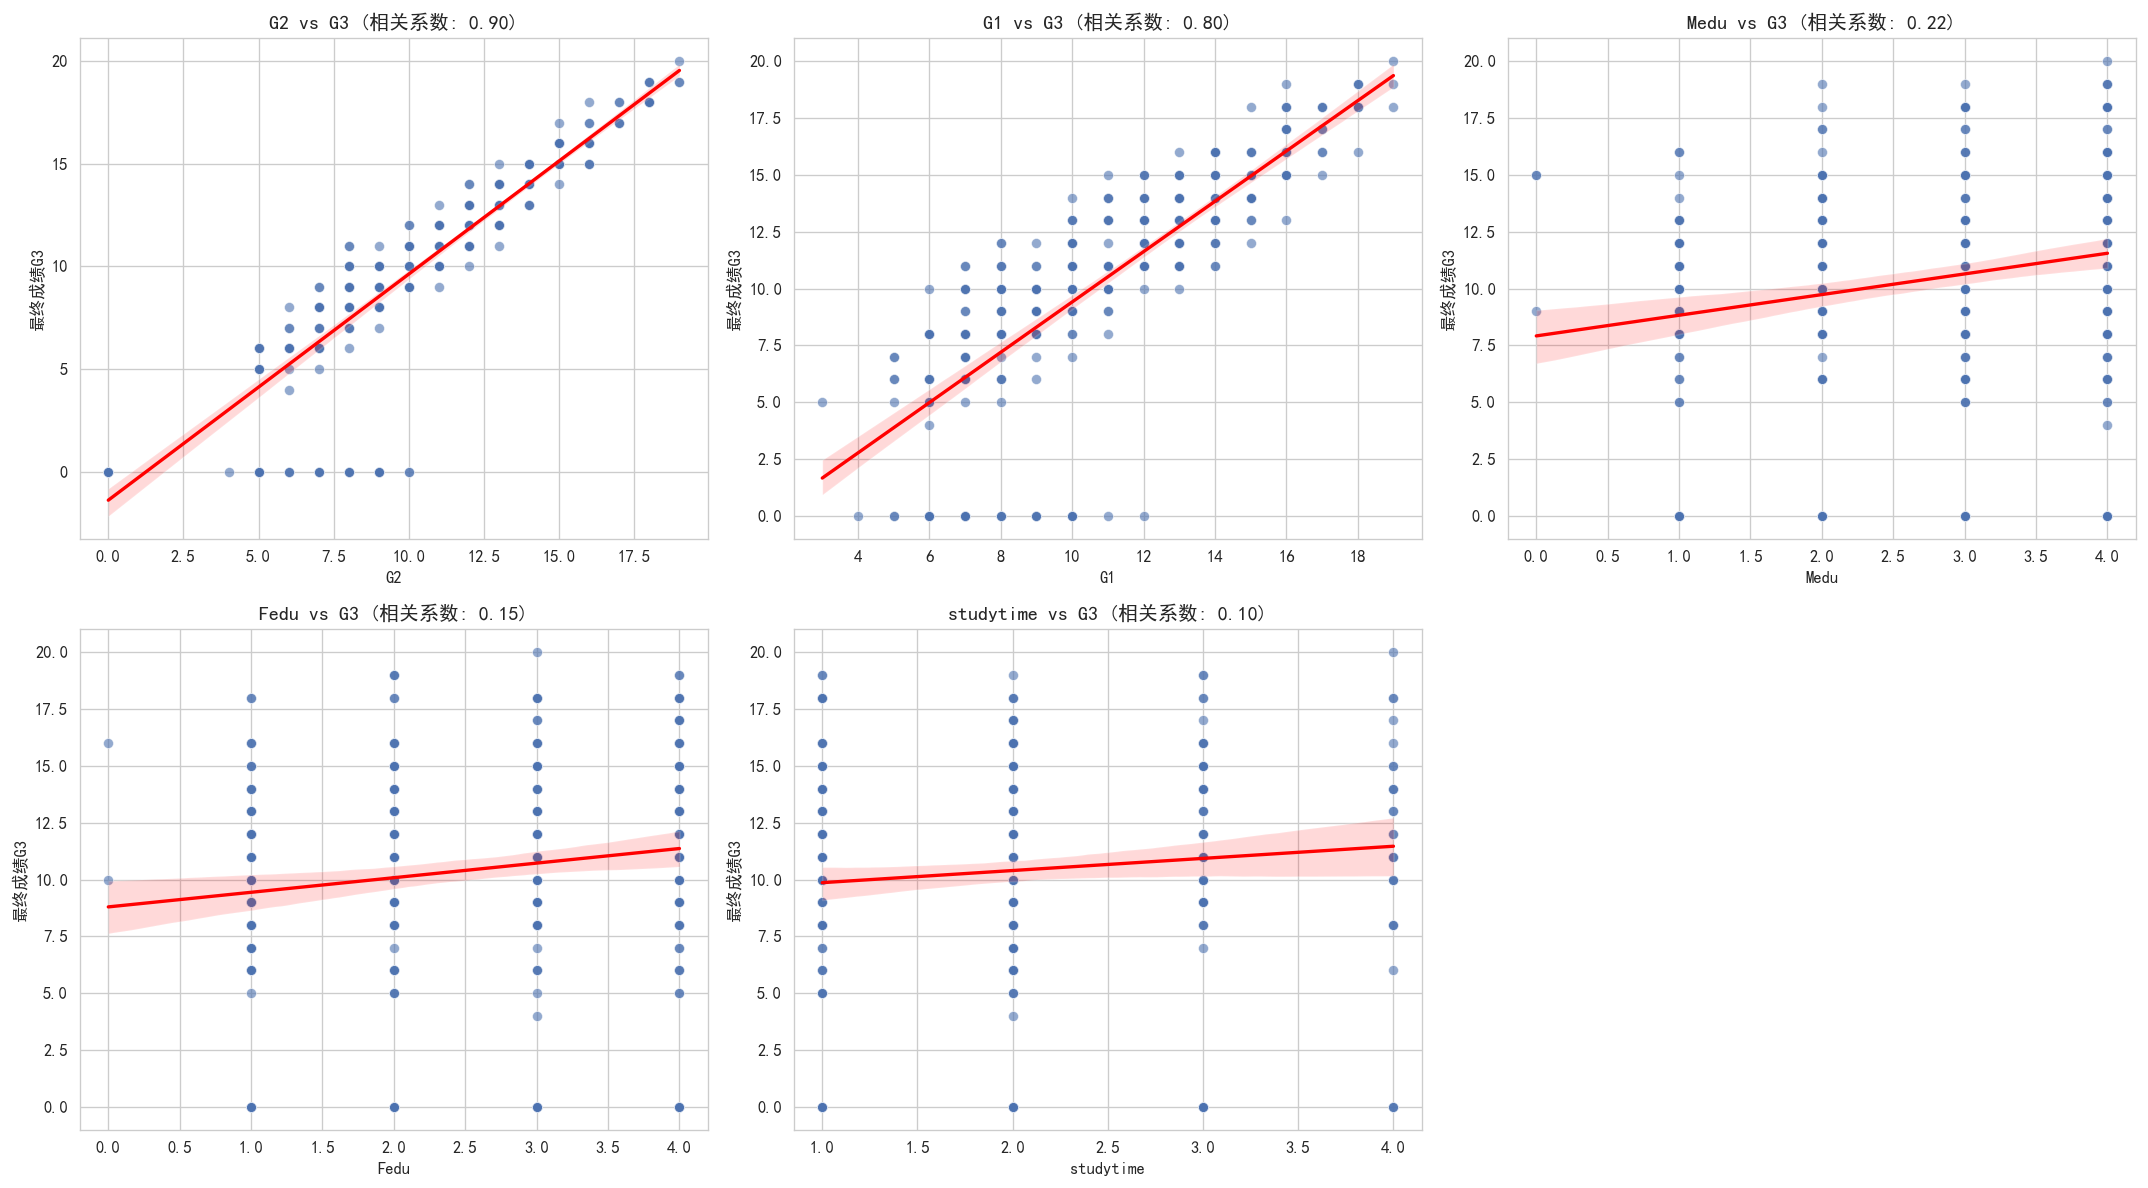

🔍 初步发现与 insights：
1. 数据集中无缺失值，数据质量良好
2. 最终成绩(G3)均值为 10.42，呈近似正态分布
3. 异常值主要集中在 absences(缺勤次数) 特征，共 83 个异常值
4. 与最终成绩最相关的特征依次是：G2(期中成绩)、G1(第一次月考)、failures(不及格次数)
5. 期中成绩G2与最终成绩G3的相关系数高达 0.90，是最强预测因子


In [1]:
# %% [markdown]
# # 01 — 数据探索与可视化
# 本 Notebook 用于初步探索学生成绩数据集。
# 
# ## 目标
# 1. 加载原始数据
# 2. 查看数据基本信息（shape, dtypes, missing values）
# 3. 描述性统计分析
# 4. 可视化单变量分布（直方图、箱线图）
# 5. 可视化双变量关系（相关性热力图、散点图）
# 6. 初步发现与 insights

# %% [markdown]
# ## 1. 导入库
# %%
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# 全局绘图配置
sns.set_style("whitegrid")
plt.rcParams['font.family'] = ['SimHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.dpi'] = 120

# 自动创建输出目录
import os
os.makedirs("../outputs/figures", exist_ok=True)

# %% [markdown]
# ## 2. 加载原始数据
# %%
df = pd.read_csv("../data/raw/student-mat.csv", sep=";")
print(f"✅ 数据加载成功，共 {df.shape[0]} 行，{df.shape[1]} 列")

# %% [markdown]
# ## 3. 查看数据基本信息
# %%
# 查看前5行数据
print("📊 数据前5行：")
print(df.head())

# 查看数据类型
print("\n📋 数据类型：")
print(df.dtypes)

# 查看缺失值
print("\n❌ 缺失值统计：")
print(df.isnull().sum())

# %% [markdown]
# ## 4. 描述性统计分析
# %%
print("📈 数值型特征描述性统计：")
print(df.describe().round(2))

# %% [markdown]
# ## 5. 可视化单变量分布
# %% [markdown]
# ### 5.1 目标变量(G3)分布
# %%
plt.figure(figsize=(10, 6))
sns.histplot(df["G3"], bins=20, kde=True, color="#4c72b0", edgecolor='black')
plt.title("最终成绩(G3)分布", fontweight='bold')
plt.xlabel("成绩")
plt.ylabel("学生数量")
plt.axvline(df["G3"].mean(), color='red', linestyle='--', label=f'均值: {df["G3"].mean():.2f}')
plt.legend()
plt.tight_layout()
plt.savefig("../outputs/figures/g3_distribution.png", dpi=300, bbox_inches='tight')
plt.show()

# %% [markdown]
# ### 5.2 数值特征异常值检测
# %%
# 定义异常值计算函数
def count_outliers(series):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return len(series[(series < lower_bound) | (series > upper_bound)])

# 按特征量级分组
feature_groups = {
    "成绩特征 (0-20分)": ["G1", "G2", "G3"],
    "学习行为特征": ["studytime", "failures", "absences"],
    "家庭与生活特征": ["age", "Medu", "Fedu", "traveltime", "famrel"],
    "社交与健康特征": ["freetime", "goout", "Dalc", "Walc", "health"]
}

# 计算异常值统计
outlier_stats = []
for col in df.select_dtypes(include=np.number).columns:
    outlier_stats.append({"特征名称": col, "异常值数量": count_outliers(df[col])})
outlier_df = pd.DataFrame(outlier_stats).sort_values("异常值数量", ascending=False)

# 绘制分组箱线图
fig, axes = plt.subplots(2, 2, figsize=(16, 14))
axes = axes.flatten()
colors = ["#4c72b0", "#55a868", "#c44e52", "#8172b2"]

for i, (group_name, features) in enumerate(feature_groups.items()):
    ax = axes[i]
    sns.boxplot(data=df[features], ax=ax, palette=[colors[i]]*len(features), 
                flierprops={"marker": "o", "markerfacecolor": "red", "markersize": 4})
    
    # 标注异常值数量
    y_min, y_max = ax.get_ylim()
    y_padding = (y_max - y_min) * 0.15
    ax.set_ylim(y_min, y_max + y_padding)
    
    for j, feat in enumerate(features):
        count = outlier_df[outlier_df["特征名称"] == feat]["异常值数量"].values[0]
        ax.text(j, y_max + y_padding * 0.3, f"异常值: {count}", 
                ha='center', va='bottom', fontweight='bold', color='red', fontsize=7)
    
    ax.set_title(f"{group_name} 箱线图", fontweight='bold', pad=35)
    ax.set_ylabel("数值")

plt.subplots_adjust(left=0.08, right=0.95, bottom=0.12, top=0.88, wspace=0.25, hspace=0.45)
plt.savefig("../outputs/figures/outlier_analysis.png", dpi=300, bbox_inches='tight')
plt.show()

print("\n📊 异常值统计汇总：")
print(outlier_df.to_string(index=False))

# %% [markdown]
# ## 6. 可视化双变量关系
# %% [markdown]
# ### 6.1 数值特征相关性热力图
# %%
plt.figure(figsize=(14, 12))
corr = df.select_dtypes(include=np.number).corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="coolwarm", 
            center=0, square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title("数值特征相关性热力图", fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig("../outputs/figures/correlation_heatmap.png", dpi=300, bbox_inches='tight')
plt.show()

# %% [markdown]
# ### 6.2 Top5相关特征与G3的散点图
# %%
top5_corr = corr["G3"].sort_values(ascending=False).index[1:6].tolist()

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, feat in enumerate(top5_corr):
    ax = axes[i]
    sns.scatterplot(x=feat, y="G3", data=df, ax=ax, alpha=0.6, color="#4c72b0")
    sns.regplot(x=feat, y="G3", data=df, ax=ax, scatter=False, color="red", 
                line_kws={"linewidth": 2})
    ax.set_title(f"{feat} vs G3 (相关系数: {corr.loc[feat, 'G3']:.2f})", fontweight='bold')
    ax.set_xlabel(feat)
    ax.set_ylabel("最终成绩G3")

axes[-1].axis('off')
plt.tight_layout()
plt.savefig("../outputs/figures/top5_correlation_scatter.png", dpi=300, bbox_inches='tight')
plt.show()

# %% [markdown]
# ## 7. 初步发现与 insights
# %%
print("🔍 初步发现与 insights：")
print("1. 数据集中无缺失值，数据质量良好")
print(f"2. 最终成绩(G3)均值为 {df['G3'].mean():.2f}，呈近似正态分布")
print("3. 异常值主要集中在 absences(缺勤次数) 特征，共 {} 个异常值".format(outlier_df.iloc[0]['异常值数量']))
print("4. 与最终成绩最相关的特征依次是：G2(期中成绩)、G1(第一次月考)、failures(不及格次数)")
print("5. 期中成绩G2与最终成绩G3的相关系数高达 {:.2f}，是最强预测因子".format(corr.loc['G2', 'G3']))